# Tight-binding Hamiltonian numerical solutions

## Tight-binding theory
$$ H = -t \sum_{j=1}^N (a_{j+1}^\dagger a_j + a_j^\dagger a_{j+1})$$

Let 
$$a_j = \frac{1}{\sqrt N} \sum_k e^{ikj} a_k \quad,\quad a_k = \frac{1}{\sqrt N} \sum_j e^{-ikj} a_j$$

We also note, 
$$[a_k, a_k^\dagger] = \frac{1}{N} \sum_{jj'} e^{ik(j'-j)}[ a_j, a_{j'}^\dagger] = \frac{1}{N} \sum_{jj'} e^{ik(j'-j)}\delta_{jj'}=1$$

$$\sum_{j=1}^Na_{j+1}^\dagger a_j = \sum_{j=1}^N\frac{1}{N} \sum_{kl} e^{-ik} e^{i(l-k)j} a_k^\dagger a_l = \sum_{k} e^{-ik} a_k^\dagger a_k$$

$$H = -2t \sum_{k} \cos(k) a_k^\dagger a_k$$

$$ a_{N+1} = a_{1} \quad\rightarrow\quad \frac{1}{\sqrt N} \sum_k e^{ikN} e^{ik} a_k = \frac{1}{\sqrt N} \sum_k e^{ik} a_k $$
Thus $kN=2\pi n$, or $k_n = 2\pi n/N$.

Energies: $$  E_n = -2t \cos(2\pi n/N)$$
States: $$ |k_n\rangle = a_k^\dagger|0\rangle = \frac{1}{\sqrt N} \sum_j e^{ik_nj} |j\rangle$$

## Lanczos Theory

Given a state $ |\psi\rangle$ the energy is: 
$$ E[|\psi\rangle] = \frac{\langle\psi|H|\psi\rangle}{\langle\psi|\psi\rangle}$$


Let 
$$
\begin{split} 
|v_0\rangle &= \frac{|\psi\rangle}{\sqrt{\langle\psi|\psi\rangle}} \\
|\tilde v_1\rangle &= H|v_0\rangle - |v_0\rangle\langle v_0|H|v_0\rangle\\
|v_1\rangle &= \frac{|\tilde v_1\rangle}{\sqrt{\langle \tilde v_1|\tilde v_1\rangle}}\\
\end{split}
$$

Trial state: $$c_0 |v_0\rangle + c_1 |v_1\rangle$$

$$
\begin{split}
c_0 H|v_0\rangle + c_1 H|v_1\rangle &= Ec_0 |v_0\rangle + Ec_1 |v_1\rangle \\
c_0 \langle v_0|H|v_0\rangle + c_1 \langle v_0|H|v_1\rangle &= Ec_0 \\
c_0 \langle v_1|H|v_0\rangle + c_1 \langle v_1|H|v_1\rangle &= Ec_1 \\
\end{split}
$$

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [15]:
n_sites = 100
hopping = 1.0

hamiltonian = np.zeros((n_sites, n_sites))
for i in range(n_sites):
    hamiltonian[i, (i + 1) % n_sites] = -hopping
    hamiltonian[i, (i - 1) % n_sites] = -hopping

In [16]:
ks = 2 * np.pi * np.arange(1, n_sites + 1) / n_sites
energies = -2 * hopping * np.cos(ks)

for k, e in zip(ks, energies):
    print(k, e)

e_min = energies.min()
k_min = ks[np.argmin(energies)]
psi_min = np.exp(1j * np.arange(1, 1 + n_sites) * ks) / np.sqrt(n_sites)
psi_min = psi_min[:, None]

0.06283185307179587 -1.9960534568565431
0.12566370614359174 -1.9842294026289558
0.18849555921538758 -1.9645745014573774
0.25132741228718347 -1.9371663222572622
0.3141592653589793 -1.902113032590307
0.37699111843077515 -1.859552971776503
0.43982297150257105 -1.8096541049320392
0.5026548245743669 -1.7526133600877272
0.5654866776461628 -1.6886558510040302
0.6283185307179586 -1.618033988749895
0.6911503837897545 -1.5410264855515785
0.7539822368615503 -1.457937254842823
0.8168140899333463 -1.3690942118573772
0.8796459430051421 -1.2748479794973795
0.9424777960769378 -1.1755705045849465
1.0053096491487339 -1.071653589957993
1.0681415022205298 -0.9635073482034303
1.1309733552923256 -0.8515585831301453
1.1938052083641213 -0.7362491053693562
1.2566370614359172 -0.6180339887498949
1.3194689145077132 -0.4973797743297095
1.382300767579509 -0.3747626291714495
1.4451326206513047 -0.25066646712860896
1.5079644737231006 -0.12558103905862705
1.5707963267948966 -1.2246467991473532e-16
1.6336281798666925 

In [17]:
def expectation(state, operator):
    return (np.conj(state.T) @ (operator @ state)).item()

In [24]:
v0 = np.random.rand(n_sites) + 1j * np.random.rand(n_sites)
v0 = v0[:, None]
v0 /= np.linalg.norm(v0)

energy_hist = []

e0 = expectation(v0, hamiltonian).real
energy_hist.append(e0)
print("Initial energy:", e0)


for i in range(20):
    v1 = hamiltonian @ v0 - e0 * v0
    v1 /= np.linalg.norm(v1)
    e1 = expectation(v1, hamiltonian).real

    gamma = (np.conj(v0.T) @ (hamiltonian @ v1)).item()

    z = np.sqrt((e0 - e1) ** 2 + 4 * np.abs(gamma) ** 2)
    # lambda0 = (e0+e1 +z) * 0.5
    lambda1 = (e0 + e1 - z) * 0.5

    vec = np.array([1.0, (-e0 + e1 - z) / (2 * gamma)])
    vec /= np.linalg.norm(vec)
    v0 = vec[0] * v0 + vec[1] * v1
    v0 /= np.linalg.norm(v0)

    e0 = expectation(v0, hamiltonian).real
    energy_hist.append(e0)
    print("energy: ", e0)

energy_hist = np.array(energy_hist)

Initial energy: -1.5262386482590373
energy:  -1.9549613311253358
energy:  -1.9840270683287682
energy:  -1.9913173247354934
energy:  -1.9945700060730245
energy:  -1.9962878534019197
energy:  -1.9973170947138905
energy:  -1.9979763960018242
energy:  -1.9984233237382552
energy:  -1.9987366292628888
energy:  -1.998963369813452
energy:  -1.999131114095604
energy:  -1.9992581371114344
energy:  -1.9993560491363773
energy:  -1.9994330418037483
energy:  -1.9994945487437301
energy:  -1.999544578561565
energy:  -1.9995858593387807
energy:  -1.999620478503692
energy:  -1.9996498816633912
energy:  -1.999675210600353


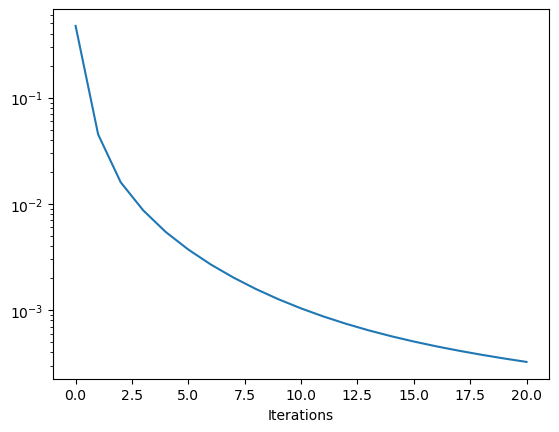

In [25]:
error = energy_hist - e_min

plt.plot(error)
plt.xlabel("Iterations")
plt.yscale("log")
plt.show()

In [26]:
overlap = np.conj(v0.real.T) @ psi_min
infidelity = 1.0 - np.abs(overlap) ** 2
print(infidelity)

[[0.99150389]]


In [28]:
v0

array([[0.06560534+0.07340658j],
       [0.06480553+0.07437459j],
       [0.06363463+0.07621182j],
       [0.06257374+0.07739548j],
       [0.06158338+0.07944501j],
       [0.06106742+0.08091807j],
       [0.06096528+0.08297336j],
       [0.06142326+0.08426272j],
       [0.06230842+0.08564977j],
       [0.06349425+0.08609032j],
       [0.06484873+0.08633936j],
       [0.06610577+0.08582253j],
       [0.06727493+0.08527394j],
       [0.06807819+0.08447182j],
       [0.06875274+0.08403526j],
       [0.06898425+0.08376231j],
       [0.0692208 +0.08404295j],
       [0.06896555+0.08444853j],
       [0.0688404 +0.08519926j],
       [0.06807269+0.08566311j],
       [0.06748546+0.08609834j],
       [0.06609411+0.08585176j],
       [0.06496892+0.08538182j],
       [0.06306078+0.08414129j],
       [0.06164215+0.08279029j],
       [0.05969484+0.08088718j],
       [0.05853463+0.07918846j],
       [0.05717045+0.07728816j],
       [0.05678044+0.07592293j],
       [0.05636456+0.07463606j],
       [0.

$$
H = \begin{pmatrix}
e_0 & \gamma \\
\gamma^* & e_1 \\
\end{pmatrix}
$$

$$ (e_0-\lambda)(e_1-\lambda) -|\gamma|^2=0$$
$$ \lambda^2 -\lambda(e_0+e_1) + e_0e_1 -|\gamma|^2=0$$


$$ \lambda = \frac{e_0+e_1\pm \sqrt{(e_0-e_1)^2+4|\gamma|^2}}{2}$$

Let $$ z = \sqrt{(e_0-e_1)^2+4|\gamma|^2}$$
$$ \lambda = \frac{e_0+e_1\pm z}{2}$$


$$e_0 c_0 + \gamma c_1 = \frac{e_0+e_1\pm z}{2}c_0$$

$$c_1 = \frac{-e_0+e_1\pm z}{2\gamma}c_0$$